# Training MobileNetV2 Transfer Learning per FER-2013

Questo notebook addestra un modello MobileNetV2 pre-addestrato su ImageNet per il riconoscimento delle emozioni facciali nel dataset FER-2013.

Usa gli stessi split del progetto:

- `data/processed/train`
- `data/processed/validation`
- `data/original/test`

Ogni run viene salvata in `experiments/<timestamp>_mobilenetv2_transfer/`.
Gli output per documentazione e confronto vengono esportati in `results/`.

Nota: MobileNetV2 usa immagini RGB. Le immagini FER-2013 sono grayscale, quindi vengono caricate come RGB duplicando il canale e ridimensionate a 96x96.

## Setup

In [1]:
from pathlib import Path
from time import perf_counter
from datetime import datetime
from contextlib import contextmanager
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from keras import Model
from keras.models import load_model
from keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from tf_keras_vis.gradcam import Gradcam

def log_step(message):
    now = datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] {message}", flush=True)


@contextmanager
def timed_step(name):
    start_time = perf_counter()
    log_step(f"INIZIO - {name}")
    try:
        yield
    finally:
        elapsed = perf_counter() - start_time
        log_step(f"FINE - {name} ({elapsed:.1f}s)")


def count_images_by_class(root_dir, extension=".jpg"):
    root_dir = Path(root_dir)
    counts = {}
    if not root_dir.exists():
        return counts

    for class_dir in sorted([p for p in root_dir.iterdir() if p.is_dir()]):
        counts[class_dir.name] = len(list(class_dir.glob(f"*{extension}")))

    return counts


def history_to_frame(history, phase, start_epoch=0):
    frame = pd.DataFrame(history.history)
    frame.insert(0, "phase", phase)
    frame.insert(1, "epoch", np.arange(start_epoch, start_epoch + len(frame)))
    return frame


class EpochTimingLogger(Callback):
    def on_train_begin(self, logs=None):
        self.training_start = perf_counter()
        log_step("Training phase avviata")

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = perf_counter()
        log_step(f"Epoca {epoch + 1} avviata")

    def on_epoch_end(self, epoch, logs=None):
        elapsed = perf_counter() - self.epoch_start
        logs = logs or {}
        metrics = []
        for key in ["loss", "accuracy", "auc", "val_loss", "val_accuracy", "val_auc"]:
            if key in logs:
                metrics.append(f"{key}={logs[key]:.4f}")

        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        metrics.append(f"lr={lr:.2e}")
        log_step(f"Epoca {epoch + 1} completata in {elapsed:.1f}s - " + " | ".join(metrics))

    def on_train_end(self, logs=None):
        elapsed = perf_counter() - self.training_start
        log_step(f"Training phase terminata in {elapsed / 60:.1f} minuti")


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

log_step(f"TensorFlow: {tf.__version__}")
log_step(f"GPU disponibili: {tf.config.list_physical_devices('GPU')}")

[17:54:54] TensorFlow: 2.20.0
[17:54:54] GPU disponibili: []


## Configurazione percorsi

In [ ]:
with timed_step("Configurazione percorsi MobileNetV2"):
    current_dir = Path.cwd()
    project_root = current_dir if (current_dir / "data").exists() else current_dir.parent

    train_dir = project_root / "data" / "processed" / "train"
    validation_dir = project_root / "data" / "processed" / "validation"
    test_dir = project_root / "data" / "original" / "test"

    experiments_root = project_root / "experiments"
    results_root = project_root / "results"
    results_figures_dir = results_root / "figures"
    results_tables_dir = results_root / "tables"
    results_predictions_dir = results_root / "predictions"

    for output_dir in [experiments_root, results_figures_dir, results_tables_dir, results_predictions_dir]:
        output_dir.mkdir(parents=True, exist_ok=True)

    IMG_HEIGHT = 48
    IMG_WIDTH = 48
    BATCH_SIZE = 32
    FEATURE_EPOCHS = 15
    FINE_TUNE_EPOCHS = 20
    FINE_TUNE_LAST_LAYERS = 30
    FEATURE_LEARNING_RATE = 1e-3
    FINE_TUNE_LEARNING_RATE = 1e-5

    if not train_dir.exists():
        raise FileNotFoundError(f"Cartella training preprocessata non trovata: {train_dir}. Esegui prima notebooks/Preprocessing.ipynb.")
    if not validation_dir.exists():
        raise FileNotFoundError(f"Cartella validation preprocessata non trovata: {validation_dir}. Esegui prima notebooks/Preprocessing.ipynb.")
    if not test_dir.exists():
        raise FileNotFoundError(f"Cartella test non trovata: {test_dir}")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_name = "mobilenetv2_transfer"
    experiment_dir = experiments_root / f"{timestamp}_{model_name}"
    experiment_dir.mkdir(parents=True, exist_ok=True)

    best_model_path = experiment_dir / "model.keras"
    feature_history_path = experiment_dir / "feature_history.csv"
    fine_tuning_history_path = experiment_dir / "fine_tuning_history.csv"
    training_history_path = experiment_dir / "training_history.csv"
    log_output_path = experiment_dir / "training_log.txt"
    config_path = experiment_dir / "config.json"
    test_results_path = experiment_dir / "test_results.txt"

    log_step(f"Project root: {project_root}")
    log_step(f"Training directory: {train_dir}")
    log_step(f"Validation directory: {validation_dir}")
    log_step(f"Test directory: {test_dir}")
    log_step(f"Experiment directory: {experiment_dir}")
    log_step(f"Input size: {IMG_HEIGHT}x{IMG_WIDTH} RGB")
    log_step(f"Batch size: {BATCH_SIZE}")

[17:54:56] INIZIO - Configurazione percorsi MobileNetV2
[17:54:56] Project root: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward
[17:54:56] Training directory: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\processed\train
[17:54:56] Validation directory: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\processed\validation
[17:54:56] Test directory: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\original\test
[17:54:56] Experiment directory: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\experiments\20260703_175456_mobilenetv2_transfer
[17:54:56] Input size: 96x96 RGB
[17:54:56] Batch size: 32
[17:54:56] FINE - Configurazione percorsi MobileNetV2 (0.0s)


## Generatori e class weights

In [3]:
with timed_step("Creazione generatori MobileNetV2 e class weights"):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode="nearest",
    )

    validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    log_step("Creo train_generator RGB con augmentation online")
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="rgb",
        class_mode="categorical",
        seed=SEED,
    )

    log_step("Creo validation_generator RGB senza augmentation")
    validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="rgb",
        class_mode="categorical",
        seed=SEED,
        shuffle=False,
    )

    log_step("Creo test_generator RGB senza augmentation")
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="rgb",
        class_mode="categorical",
        shuffle=False,
    )

    class_indices = train_generator.class_indices
    emotion_labels = {v: k for k, v in class_indices.items()}
    target_names = [emotion_labels[i] for i in range(len(emotion_labels))]

    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_generator.classes),
        y=train_generator.classes,
    )
    class_weights = dict(enumerate(class_weights_array))

    train_counts = count_images_by_class(train_dir)
    validation_counts = count_images_by_class(validation_dir)
    test_counts = count_images_by_class(test_dir)

    log_step(f"Classi: {class_indices}")
    log_step(f"Training samples: {train_generator.samples} ({len(train_generator)} batch/epoca)")
    log_step(f"Validation samples: {validation_generator.samples} ({len(validation_generator)} batch)")
    log_step(f"Test samples: {test_generator.samples} ({len(test_generator)} batch)")

    for class_name in sorted(set(train_counts) | set(validation_counts) | set(test_counts)):
        log_step(
            f"{class_name}: train={train_counts.get(class_name, 0)}, "
            f"validation={validation_counts.get(class_name, 0)}, "
            f"test={test_counts.get(class_name, 0)}"
        )

    log_step(f"Class weights: {class_weights}")

[17:55:02] INIZIO - Creazione generatori MobileNetV2 e class weights
[17:55:02] Creo train_generator RGB con augmentation online
Found 32155 images belonging to 7 classes.
[17:55:02] Creo validation_generator RGB senza augmentation
Found 5741 images belonging to 7 classes.
[17:55:03] Creo test_generator RGB senza augmentation
Found 7178 images belonging to 7 classes.
[17:55:03] Classi: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
[17:55:03] Training samples: 32155 (1005 batch/epoca)
[17:55:03] Validation samples: 5741 (180 batch)
[17:55:03] Test samples: 7178 (225 batch)
[17:55:03] angry: train=4507, validation=799, test=958
[17:55:03] disgust: train=477, validation=87, test=111
[17:55:03] fear: train=4588, validation=819, test=1024
[17:55:03] happy: train=8062, validation=1443, test=1774
[17:55:03] neutral: train=5560, validation=993, test=1233
[17:55:03] sad: train=5407, validation=966, test=1247
[17:55:03] surprise: train=3554, validation=

## Modello MobileNetV2

In [4]:
with timed_step("Costruzione MobileNetV2 transfer learning"):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )
    base_model.trainable = False

    inputs = Input(shape=(96, 96, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.30)(x)
    outputs = Dense(len(class_indices), activation="softmax")(x)
    model = Model(inputs, outputs, name="mobilenetv2_transfer_fer2013")

    model.compile(
        optimizer=Adam(learning_rate=FEATURE_LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy", AUC(name="auc")],
    )

    total_params = int(model.count_params())
    trainable_params = int(sum(np.prod(v.shape) for v in model.trainable_weights))
    non_trainable_params = total_params - trainable_params

    log_step(f"Parametri totali: {total_params:,}")
    log_step(f"Parametri trainable feature extraction: {trainable_params:,}")
    log_step(f"Parametri non trainable: {non_trainable_params:,}")
    model.summary()

[17:55:06] INIZIO - Costruzione MobileNetV2 transfer learning
[17:55:06] Parametri totali: 2,266,951
[17:55:06] Parametri trainable feature extraction: 8,967
[17:55:06] Parametri non trainable: 2,257,984


Model: "mobilenetv2_transfer_fer2013"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

[17:55:06] FINE - Costruzione MobileNetV2 transfer learning (0.9s)


## Fase 1 - Feature extraction

In [9]:
feature_callbacks = [
    EpochTimingLogger(),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint(str(best_model_path), monitor="val_loss", save_best_only=True),
]

with timed_step("Training MobileNetV2 - feature extraction"):
    feature_start = perf_counter()
    feature_history = model.fit(
        train_generator,
        epochs=FEATURE_EPOCHS,
        validation_data=validation_generator,
        callbacks=feature_callbacks,
        class_weight=class_weights,
        verbose=1,
    )
    feature_train_time_seconds = perf_counter() - feature_start

feature_frame = history_to_frame(feature_history, "feature_extraction", start_epoch=0)
feature_frame.to_csv(feature_history_path, index=False)
log_step(f"Feature extraction history salvata in: {feature_history_path}")

[18:18:21] INIZIO - Training MobileNetV2 - feature extraction
[18:18:21] Training phase avviata
[18:18:21] Epoca 1 avviata
Epoch 1/15
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2374 - auc: 0.6267 - loss: 2.1719[18:20:00] Epoca 1 completata in 99.0s - loss=1.9881 | accuracy=0.2782 | auc=0.6674 | val_loss=1.6045 | val_accuracy=0.3856 | val_auc=0.7673 | lr=1.00e-03
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 99s 96ms/step - accuracy: 0.2782 - auc: 0.6674 - loss: 1.9881 - val_accuracy: 0.3856 - val_auc: 0.7673 - val_loss: 1.6045 - learning_rate: 0.0010
[18:20:00] Epoca 2 avviata
Epoch 2/15
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3264 - auc: 0.7195 - loss: 1.7754[18:21:25] Epoca 2 completata in 84.6s - loss=1.7700 | accuracy=0.3285 | auc=0.7205 | val_loss=1.5678 | val_accuracy=0.3898 | val_auc=0.7790 | lr=1.00e-03
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 85s 84ms/step - accuracy: 0.3285 - auc: 0.7205 - loss: 1.7700 - val_accuracy: 0.3898 - val_auc: 0.7790 - val_loss: 1.5678 - lear

## Fase 2 - Fine tuning

In [10]:
with timed_step("Configurazione fine tuning MobileNetV2"):
    base_model.trainable = True
    fine_tune_at = max(0, len(base_model.layers) - FINE_TUNE_LAST_LAYERS)

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # Manteniamo BatchNormalization congelata per rendere il fine tuning piu' stabile.
    for layer in base_model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy", AUC(name="auc")],
    )

    total_params = int(model.count_params())
    fine_tune_trainable_params = int(sum(np.prod(v.shape) for v in model.trainable_weights))
    fine_tune_non_trainable_params = total_params - fine_tune_trainable_params

    log_step(f"Layer totali MobileNetV2: {len(base_model.layers)}")
    log_step(f"Fine tuning dagli ultimi {FINE_TUNE_LAST_LAYERS} layer circa, indice di taglio: {fine_tune_at}")
    log_step(f"Parametri trainable fine tuning: {fine_tune_trainable_params:,}")
    log_step(f"Parametri non trainable fine tuning: {fine_tune_non_trainable_params:,}")


fine_tune_callbacks = [
    EpochTimingLogger(),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
    ModelCheckpoint(str(best_model_path), monitor="val_loss", save_best_only=True),
]

with timed_step("Training MobileNetV2 - fine tuning"):
    fine_tune_start = perf_counter()
    fine_tune_history = model.fit(
        train_generator,
        epochs=FINE_TUNE_EPOCHS,
        validation_data=validation_generator,
        callbacks=fine_tune_callbacks,
        class_weight=class_weights,
        verbose=1,
    )
    fine_tune_train_time_seconds = perf_counter() - fine_tune_start

fine_tune_frame = history_to_frame(
    fine_tune_history,
    "fine_tuning",
    start_epoch=len(feature_frame),
)
fine_tune_frame.to_csv(fine_tuning_history_path, index=False)

training_history = pd.concat([feature_frame, fine_tune_frame], ignore_index=True)
training_history.to_csv(training_history_path, index=False)

best_val_loss = float(training_history["val_loss"].min())
best_epoch = int(training_history["val_loss"].idxmin()) + 1
best_val_accuracy = float(training_history["val_accuracy"].max())
best_val_accuracy_epoch = int(training_history["val_accuracy"].idxmax()) + 1
best_val_auc = float(training_history["val_auc"].max())
best_val_auc_epoch = int(training_history["val_auc"].idxmax()) + 1

log_step(f"Training history completa salvata in: {training_history_path}")
log_step(f"Migliore val_loss: {best_val_loss:.4f} all'epoca {best_epoch}")
log_step(f"Migliore val_accuracy: {best_val_accuracy:.4f} all'epoca {best_val_accuracy_epoch}")
log_step(f"Migliore val_auc: {best_val_auc:.4f} all'epoca {best_val_auc_epoch}")

[18:33:55] INIZIO - Configurazione fine tuning MobileNetV2
[18:33:55] Layer totali MobileNetV2: 154
[18:33:55] Fine tuning dagli ultimi 30 layer circa, indice di taglio: 124
[18:33:55] Parametri trainable fine tuning: 1,519,687
[18:33:55] Parametri non trainable fine tuning: 747,264
[18:33:55] FINE - Configurazione fine tuning MobileNetV2 (0.0s)
[18:33:55] INIZIO - Training MobileNetV2 - fine tuning
[18:33:55] Training phase avviata
[18:33:55] Epoca 1 avviata
Epoch 1/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.3509 - auc: 0.7426 - loss: 1.6637[18:35:38] Epoca 1 completata in 102.5s - loss=1.6209 | accuracy=0.3641 | auc=0.7532 | val_loss=1.5351 | val_accuracy=0.4123 | val_auc=0.7863 | lr=1.00e-05
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 103s 99ms/step - accuracy: 0.3641 - auc: 0.7532 - loss: 1.6209 - val_accuracy: 0.4123 - val_auc: 0.7863 - val_loss: 1.5351 - learning_rate: 1.0000e-05
[18:35:38] Epoca 2 avviata
Epoch 2/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.

## Curve di apprendimento

[19:07:52] INIZIO - Creazione curve MobileNetV2
[19:07:52] Curve di apprendimento salvate in: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\results\figures\20260628_181653_mobilenetv2_transfer_training_curves.png


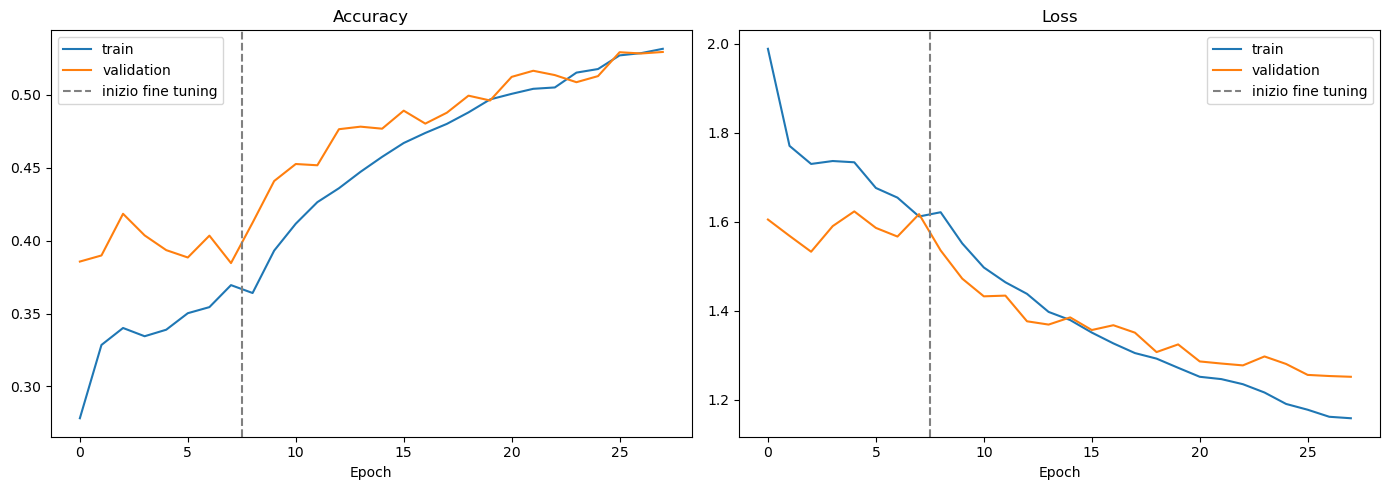

[19:07:52] FINE - Creazione curve MobileNetV2 (0.4s)


In [11]:
with timed_step("Creazione curve MobileNetV2"):
    fig = plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(training_history["epoch"], training_history["accuracy"], label="train")
    plt.plot(training_history["epoch"], training_history["val_accuracy"], label="validation")
    plt.axvline(len(feature_frame) - 0.5, color="gray", linestyle="--", label="inizio fine tuning")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(training_history["epoch"], training_history["loss"], label="train")
    plt.plot(training_history["epoch"], training_history["val_loss"], label="validation")
    plt.axvline(len(feature_frame) - 0.5, color="gray", linestyle="--", label="inizio fine tuning")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()

    curves_path = results_figures_dir / f"{experiment_dir.name}_training_curves.png"
    fig.savefig(curves_path, dpi=150, bbox_inches="tight")
    log_step(f"Curve di apprendimento salvate in: {curves_path}")

    plt.show()

## Valutazione finale sul test set

[17:55:14] INIZIO - Valutazione finale MobileNetV2 sul test set
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.2056 - auc: 0.5627 - loss: 2.1958
[17:55:25] Test loss: 2.1958
[17:55:25] Test accuracy: 0.2056
[17:55:25] Test AUC: 0.5627
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step
[17:55:35] Classification report
              precision    recall  f1-score   support

       angry       0.09      0.04      0.05       958
     disgust       0.01      0.05      0.02       111
        fear       0.19      0.08      0.11      1024
       happy       0.29      0.46      0.36      1774
     neutral       0.16      0.22      0.19      1233
         sad       0.23      0.07      0.11      1247
    surprise       0.16      0.21      0.18       831

    accuracy                           0.21      7178
   macro avg       0.16      0.16      0.15      7178
weighted avg       0.20      0.21      0.18      7178

[17:55:35] Confusion matrix
[[ 37  52  60 363 283  57 106]
 [  7   5  13  41  30  

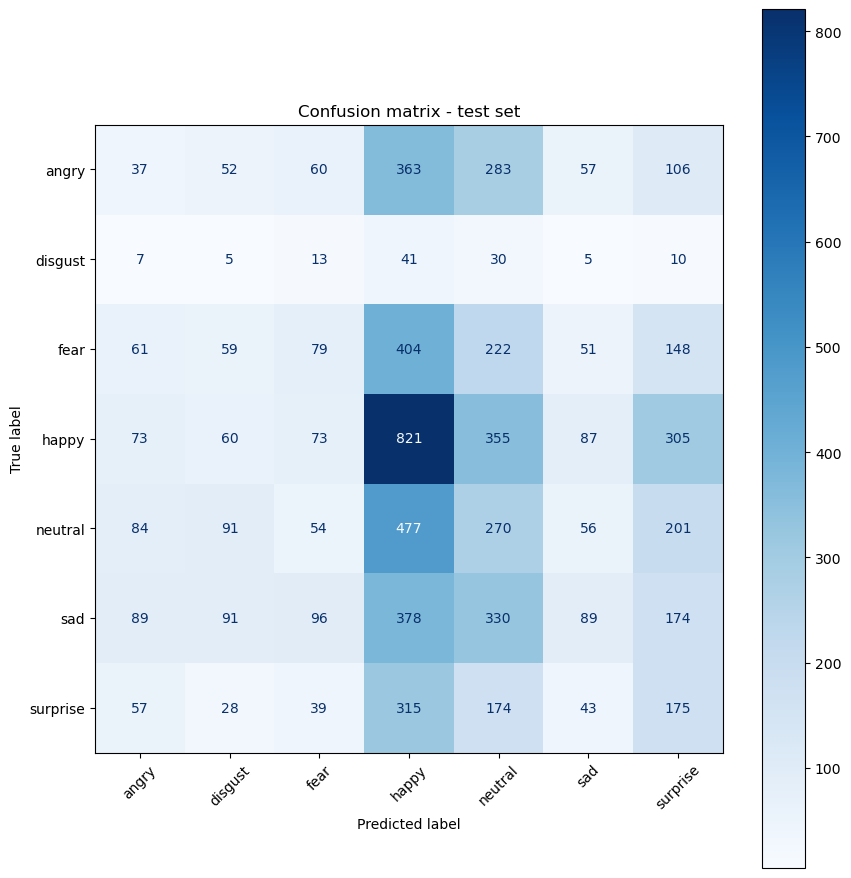

[17:55:35] FINE - Valutazione finale MobileNetV2 sul test set (20.7s)


NameError: name 'feature_train_time_seconds' is not defined

In [5]:
with timed_step("Valutazione finale MobileNetV2 sul test set"):
    if best_model_path.exists():
        log_step(f"Carico il miglior modello salvato: {best_model_path}")
        model = load_model(best_model_path)

    evaluate_start = perf_counter()
    test_loss, test_accuracy, test_auc = model.evaluate(test_generator, verbose=1)
    evaluate_time_seconds = perf_counter() - evaluate_start

    log_step(f"Test loss: {test_loss:.4f}")
    log_step(f"Test accuracy: {test_accuracy:.4f}")
    log_step(f"Test AUC: {test_auc:.4f}")

    predict_start = perf_counter()
    y_true = test_generator.classes
    y_pred_proba = model.predict(test_generator, verbose=1)
    predict_time_seconds = perf_counter() - predict_start
    y_pred = np.argmax(y_pred_proba, axis=1)

    inference_time_ms_per_image = (predict_time_seconds / test_generator.samples) * 1000

    class_report = classification_report(y_true, y_pred, target_names=target_names)
    class_report_dict = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True,
    )
    conf_matrix = confusion_matrix(y_true, y_pred)

    log_step("Classification report")
    print(class_report)

    log_step("Confusion matrix")
    print(conf_matrix)

    with open(test_results_path, "w", encoding="utf-8") as f:
        f.write("=== VALUTAZIONE FINALE SUL TEST SET ===\n\n")
        f.write(f"Test Loss: {test_loss:.4f}\n")
        f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
        f.write(f"Test AUC: {test_auc:.4f}\n")
        f.write(f"Macro F1: {class_report_dict['macro avg']['f1-score']:.4f}\n")
        f.write(f"Weighted F1: {class_report_dict['weighted avg']['f1-score']:.4f}\n")
        f.write(f"Inference time: {inference_time_ms_per_image:.4f} ms/image\n\n")
        f.write("=== CLASSIFICATION REPORT ===\n")
        f.write(class_report)
        f.write("\n=== CONFUSION MATRIX ===\n")
        f.write(np.array2string(conf_matrix))

    report_csv_path = results_tables_dir / f"{experiment_dir.name}_classification_report.csv"
    confusion_csv_path = results_tables_dir / f"{experiment_dir.name}_confusion_matrix.csv"
    predictions_csv_path = results_predictions_dir / f"{experiment_dir.name}_test_predictions.csv"
    confusion_fig_path = results_figures_dir / f"{experiment_dir.name}_confusion_matrix.png"

    pd.DataFrame(class_report_dict).transpose().to_csv(report_csv_path)
    pd.DataFrame(conf_matrix, index=target_names, columns=target_names).to_csv(confusion_csv_path)

    predictions_df = pd.DataFrame(
        {
            "filepath": test_generator.filepaths,
            "true_label": [target_names[i] for i in y_true],
            "predicted_label": [target_names[i] for i in y_pred],
        }
    )
    for class_index, class_name in enumerate(target_names):
        predictions_df[f"prob_{class_name}"] = y_pred_proba[:, class_index]
    predictions_df.to_csv(predictions_csv_path, index=False)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=target_names)
    fig, ax = plt.subplots(figsize=(9, 9))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    plt.title("Confusion matrix - test set")
    plt.tight_layout()
    fig.savefig(confusion_fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    model_size_mb = best_model_path.stat().st_size / (1024 * 1024) if best_model_path.exists() else 0.0
    total_train_time_seconds = feature_train_time_seconds + fine_tune_train_time_seconds

    config = {
        "model_name": model_name,
        "timestamp": timestamp,
        "pretrained_weights": "imagenet",
        "base_model": "MobileNetV2",
        "input_shape": [IMG_HEIGHT, IMG_WIDTH, 3],
        "batch_size": BATCH_SIZE,
        "feature_epochs": FEATURE_EPOCHS,
        "fine_tune_epochs": FINE_TUNE_EPOCHS,
        "fine_tune_last_layers": FINE_TUNE_LAST_LAYERS,
        "feature_learning_rate": FEATURE_LEARNING_RATE,
        "fine_tune_learning_rate": FINE_TUNE_LEARNING_RATE,
        "optimizer": "Adam",
        "loss": "categorical_crossentropy",
        "metrics": ["accuracy", "auc"],
        "class_weight": {str(k): float(v) for k, v in class_weights.items()},
        "train_dir": str(train_dir.relative_to(project_root)),
        "validation_dir": str(validation_dir.relative_to(project_root)),
        "test_dir": str(test_dir.relative_to(project_root)),
        "output_dir": str(experiment_dir.relative_to(project_root)),
        "total_params": int(model.count_params()),
        "feature_trainable_params": int(trainable_params),
        "fine_tune_trainable_params": int(fine_tune_trainable_params),
        "model_size_mb": float(model_size_mb),
        "feature_train_time_seconds": float(feature_train_time_seconds),
        "fine_tune_train_time_seconds": float(fine_tune_train_time_seconds),
        "total_train_time_seconds": float(total_train_time_seconds),
        "evaluate_time_seconds": float(evaluate_time_seconds),
        "predict_time_seconds": float(predict_time_seconds),
        "inference_time_ms_per_image": float(inference_time_ms_per_image),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy),
        "test_auc": float(test_auc),
        "macro_f1": float(class_report_dict["macro avg"]["f1-score"]),
        "weighted_f1": float(class_report_dict["weighted avg"]["f1-score"]),
        "best_val_loss": float(best_val_loss),
        "best_val_loss_epoch": int(best_epoch),
        "best_val_accuracy": float(best_val_accuracy),
        "best_val_accuracy_epoch": int(best_val_accuracy_epoch),
        "best_val_auc": float(best_val_auc),
        "best_val_auc_epoch": int(best_val_auc_epoch),
    }

    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2)

    with open(log_output_path, "w", encoding="utf-8") as f:
        f.write(f"Modello: {model_name}\n")
        f.write(f"Data: {timestamp}\n")
        f.write(f"Base model: MobileNetV2 pretrained on ImageNet\n")
        f.write(f"Migliore val_loss: {best_val_loss:.4f} all'epoca {best_epoch}\n")
        f.write(f"Test accuracy: {test_accuracy:.4f}\n")
        f.write(f"Test AUC: {test_auc:.4f}\n")
        f.write(f"Macro F1: {class_report_dict['macro avg']['f1-score']:.4f}\n")
        f.write(f"Weighted F1: {class_report_dict['weighted avg']['f1-score']:.4f}\n")
        f.write(f"Training totale: {total_train_time_seconds / 60:.1f} minuti\n")
        f.write(f"Inference time: {inference_time_ms_per_image:.4f} ms/image\n")

    comparison_path = results_tables_dir / "models_comparison.csv"
    comparison_row = {
        "experiment_name": experiment_dir.name,
        "model_name": model_name,
        "base_model": "MobileNetV2",
        "pretrained_weights": "imagenet",
        "input_size": f"{IMG_HEIGHT}x{IMG_WIDTH}x3",
        "test_accuracy": float(test_accuracy),
        "macro_f1": float(class_report_dict["macro avg"]["f1-score"]),
        "weighted_f1": float(class_report_dict["weighted avg"]["f1-score"]),
        "test_auc": float(test_auc),
        "num_params": int(model.count_params()),
        "model_size_mb": float(model_size_mb),
        "train_time_seconds": float(total_train_time_seconds),
        "inference_time_ms_per_image": float(inference_time_ms_per_image),
        "experiment_dir": str(experiment_dir.relative_to(project_root)),
    }

    if comparison_path.exists():
        comparison_df = pd.read_csv(comparison_path)
        comparison_df = comparison_df[comparison_df["experiment_name"] != experiment_dir.name]
        comparison_df = pd.concat([comparison_df, pd.DataFrame([comparison_row])], ignore_index=True)
    else:
        comparison_df = pd.DataFrame([comparison_row])
    comparison_df.to_csv(comparison_path, index=False)

    log_step(f"Risultati del test salvati in: {test_results_path}")
    log_step(f"Config salvata in: {config_path}")
    log_step(f"Classification report CSV salvato in: {report_csv_path}")
    log_step(f"Confusion matrix CSV salvata in: {confusion_csv_path}")
    log_step(f"Predizioni test salvate in: {predictions_csv_path}")
    log_step(f"Confusion matrix PNG salvata in: {confusion_fig_path}")
    log_step(f"Tabella confronto modelli aggiornata in: {comparison_path}")

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

experiment_dir = Path(r"C:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\experiments\20260628_181653_mobilenetv2_transfer")
model_path = experiment_dir / "model.keras"

log_step(f"Caricamento del modello da: {model_path}...")
model = tf.keras.models.load_model(model_path)

log_step("Generazione delle mappe Grad-CAM per 12 immagini di esempio...")

def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Genera la heatmap Grad-CAM nativa identificando i layer in modo dinamico."""
    
    # 1. Recuperiamo i componenti cercando per tipo o stringa parziale
    base_model = model.get_layer("mobilenetv2_1.00_96")
    
    # Cerchiamo i layer successivi dinamicamente per evitare il problema dei suffissi numerici (_1, _2...)
    gap_layer = None
    dropout_layer = None
    dense_layer = None
    
    for layer in model.layers:
        if "global_average_pooling2d" in layer.name:
            gap_layer = layer
        elif "dropout" in layer.name:
            dropout_layer = layer
        elif "dense" in layer.name:
            dense_layer = layer

    # Controllo di sicurezza se qualcosa dovesse mancare
    if not all([gap_layer, dropout_layer, dense_layer]):
        raise ValueError("Impossibile mappare i layer custom. Verifica la struttura del modello.")
    
    # 2. Creiamo un modello intermedio solo per la parte convoluzionale di MobileNetV2
    base_grad_model = tf.keras.models.Model(
        base_model.inputs, 
        base_model.get_layer(last_conv_layer_name).output
    )
    
    # 3. Eseguiamo il passaggio in avanti nel GradientTape (il resto rimane identico)
    with tf.GradientTape() as tape:
        last_conv_layer_output = base_grad_model(img_array)
        
        x = gap_layer(last_conv_layer_output)
        x = dropout_layer(x)
        preds = dense_layer(x)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Calcolo dei gradienti
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # 5. Generazione della heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()


# 1. Identifichiamo l'ultimo livello convoluzionale di MobileNetV2
last_conv_layer_name = "out_relu" 

# 2. Resettiamo il generatore ed estraiamo i dati per 12 immagini
test_generator.reset()

gradcam_images = []
gradcam_labels_true = []
gradcam_labels_pred = []
gradcam_heatmaps = []

# Cicliamo sul generatore finché non raccogliamo almeno 12 immagini
compiled_images = 0
for x_batch, y_batch in test_generator:
    preds_batch = model.predict(x_batch, verbose=0)
    
    for i in range(len(x_batch)):
        if compiled_images >= 12:
            break
            
        img = x_batch[i]
        true_idx = np.argmax(y_batch[i])
        pred_idx = np.argmax(preds_batch[i])
        
        img_input = np.expand_dims(img, axis=0)
        
        # Generiamo la heatmap per la classe predetta
        heatmap = get_gradcam_heatmap(img_input, model, last_conv_layer_name, pred_index=pred_idx)        
        gradcam_images.append(img)
        gradcam_labels_true.append(target_names[true_idx])
        gradcam_labels_pred.append(target_names[pred_idx])
        gradcam_heatmaps.append(heatmap)
        
        compiled_images += 1
        
    if compiled_images >= 12:
        break

# 3. Creiamo la griglia di visualizzazione (4 righe x 3 colonne)
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
axes = axes.ravel()

for i in range(12):
    img_display = gradcam_images[i]
    if img_display.min() < 0:
        img_display = (img_display + 1.0) / 2.0
    img_display = np.clip(img_display, 0, 1)

    # Ridimensioniamo la heatmap per farla combaciare con l'immagine originale
    heatmap_resized = cv2.resize(gradcam_heatmaps[i], (img_display.shape[1], img_display.shape[0]))
    
    # Convertiamo la heatmap in formato Jet colorato
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

    # Sovrapponiamo l'immagine originale e la heatmap (risolto errore dtype forzando float64 o calcolo numpy)
    superimposed_img = (img_display * 0.6) + (heatmap_colored * 0.4)
    superimposed_img = np.clip(superimposed_img, 0, 1)

    # Plot nel subplot dedicato
    ax = axes[i]
    ax.imshow(superimposed_img)
    
    title_color = "green" if gradcam_labels_true[i] == gradcam_labels_pred[i] else "red"
    ax.set_title(f"True: {gradcam_labels_true[i]}\nPred: {gradcam_labels_pred[i]}", color=title_color, fontsize=10)
    ax.axis("off")

plt.tight_layout()

# 4. Salviamo la figura generata nel tuo percorso figure
gradcam_fig_path = results_figures_dir / f"{experiment_dir.name}_gradcam_examples.png"
fig.savefig(gradcam_fig_path, dpi=150, bbox_inches="tight")
plt.show()

log_step(f"Esempi Grad-CAM salvati in: {gradcam_fig_path}")

[18:24:33] Caricamento del modello da: C:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\experiments\20260629_185100_cnn_complex_v1\model.keras...


TypeError: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'cnn_complex_v1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 2223266879760}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 48, 48, 1], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_layer', 'optional': False}, 'registered_name': None}, {'module': 'keras.layers', 'class_name': 'Conv2D', 'config': {'name': 'conv2d', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'filters': 32,

## Note per il confronto

Questa run serve per confrontare la CNN custom con un modello pre-addestrato.

Per la presentazione e il README usare:

- `experiments/<run>/{config.json, model.keras, training_history.csv, training_log.txt, test_results.txt}`
- `results/tables/models_comparison.csv`
- `results/figures/<run>_training_curves.png`
- `results/figures/<run>_confusion_matrix.png`
- `results/predictions/<run>_test_predictions.csv`